ref: ../mhn/test_calculate_metrics

benchmark method and 

In [1]:
import cafe

cafe.logger.setLevel("DEBUG")

[10/27/2025 08:10:47] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

read trajectory result

[10/27/2025 08:10:48] DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    unserialize trajectory dict: '20251020_161304__scvelo-cfe_docker__JV5pLHC89R'                                                                                            
                      DEBUG    parse 'MilestoneWrapper' object for 20251020_161304__scvelo-cfe_docker__JV5pLHC89R                                                                                   

<Axes: title={'center': 'stavia-cfe_docker(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>

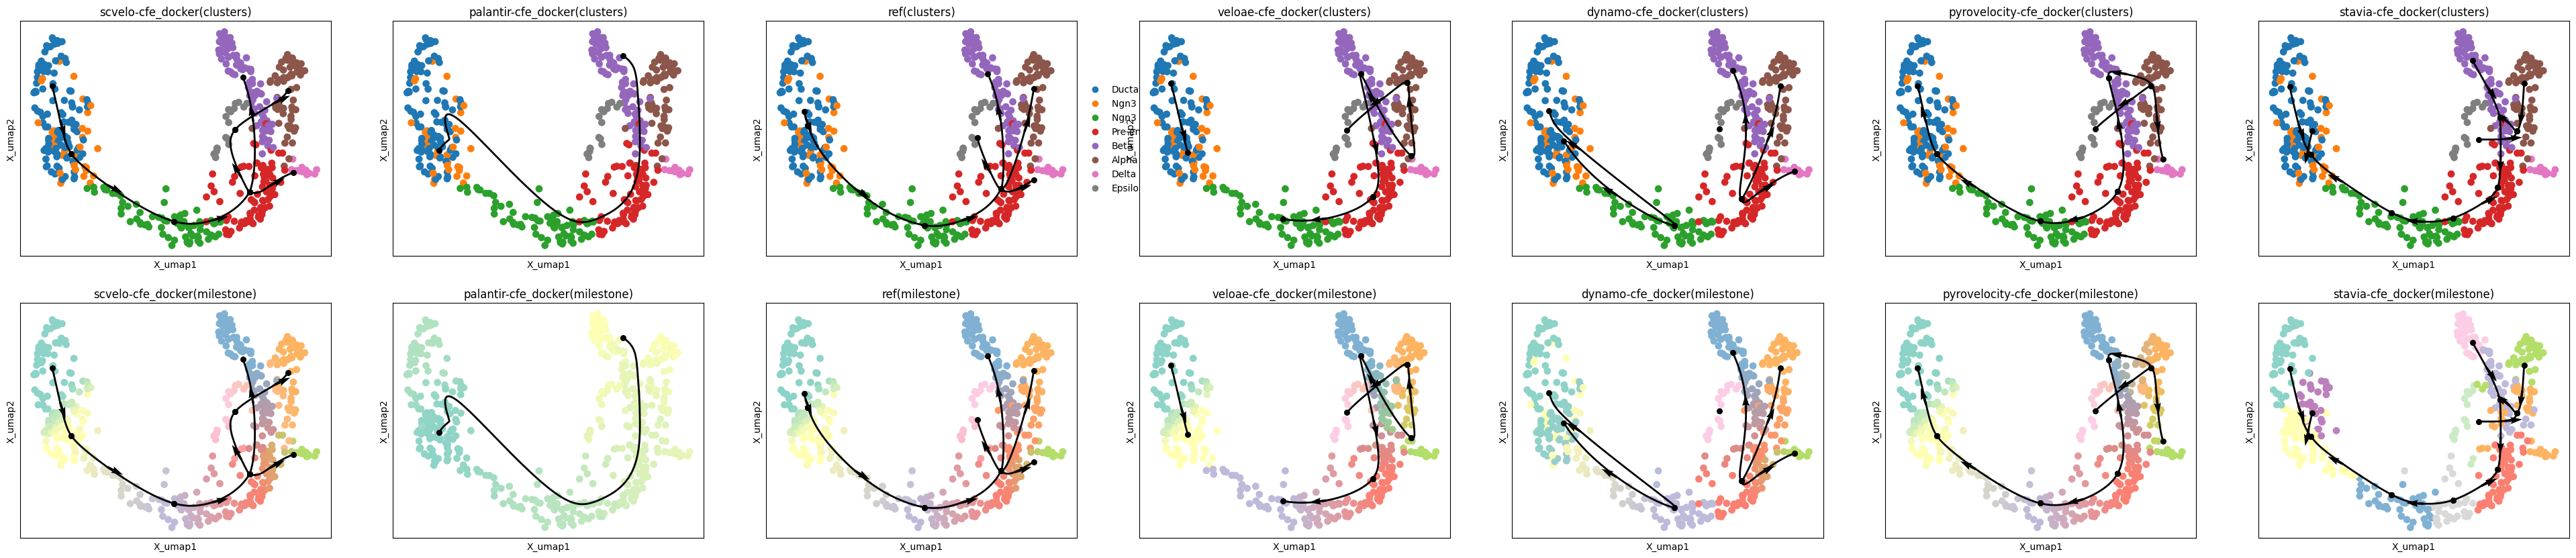

In [2]:
fadata = cafe.data.read_h5ad("output.h5ad")
fadata.id = "benchmark_pancrease_500"
# fadata.load_trajectory_dict(model_name_list=["20251023_163939__veloae-cfe_docker__M3CJuMqPQC"]) # load one trajectory
fadata.load_trajectory_dict() # load all trajectories

model_name_list = fadata.get_all_model_name(parse=False)
color_list = ["clusters", "milestone"]

cafe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

calculate metric

In [ ]:
# metrics = [
#     "pseudotime_correlation",
#     "velocity_cbdir",
#     "velocity_icvcoh",
#     "isomorphic",
#     "edge_flip",
#     "him",
#     "correlation",
#     "F1_branches",
#     "F1_milestones",
# ]
metrics = None  # calculate all metrics

cluster_edges = {
    ("Ductal", "Ngn3 low EP"),
    ("Ngn3 low EP", "Ngn3 high EP"),
    ("Ngn3 high EP", "Pre-endocrine"),
    ("Pre-endocrine", "Alpha"),
    ("Pre-endocrine", "Beta"),
    ("Pre-endocrine", "Delta"),
    ("Pre-endocrine", "Epsilon"),
}

metric_df = cafe.metric.calculate_metrics(fadata, metrics=metrics, cluster_edges=cluster_edges)
metric_df.to_csv(f"{fadata.id}_metric_df.csv")
metric_df

[10/27/2025 08:12:14] DEBUG    start_milestone is None, try to use start cell to identify start milestone automatically                                                                                 
                      DEBUG    extract start_cell('cell_000') from prior information                                                                                                                    
                      DEBUG    find start milestone 'Ductal' from start cell 'cell_000'                                                                                                                 
                      DEBUG    calculating new pseudotime                                                                                                                                               
                      DEBUG    save pseudotime to trajectory dict with key: `pseudotime_from_Ductal`                                                                                                

,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,rf_mse,rf_nmse,rf_rsq,lm_nmse,lm_mse,lm_rsq,featureimp_cor,featureimp_wcor
20251020_161304__scvelo-cfe_docker__JV5pLHC89R,0.983015,0.457708,0.858215,0,0.857143,0.794244,NaN,0.867640,0.963859,0.002185,0.972168,0.957188,0.978683,0.001673,0.966811,0.994058,0.988435
20251020_161314__palantir-cfe_docker__HciMibnvCH,0.922941,0.419304,0.998264,0,0.000000,0.272876,NaN,0.187328,0.284390,0.052462,0.331644,0.341132,0.207983,0.062168,0.162472,0.678450,0.681469
20251023_163939__veloae-cfe_docker__M3CJuMqPQC,0.122569,-0.146296,0.801720,0,0.333333,0.651636,0.690388,0.562070,0.884291,0.003819,0.951343,0.932226,0.914799,0.006688,0.861907,0.980875,0.959519
20251022_205738__dynamo-cfe_docker__TkPAXz8iQN,0.014139,0.513167,0.626976,0,0.500000,0.791603,0.663184,0.786922,0.835423,0.005983,0.923783,0.935697,0.822032,0.013969,0.859472,0.971316,0.955790
20251023_160917__pyrovelocity-cfe_docker__Gy3iknkAcS,-0.014370,0.198281,0.652607,0,0.500000,0.803986,0.726667,0.622690,0.917672,0.004216,0.946287,0.927230,0.938895,0.004796,0.902007,0.989099,0.978134
20251023_164833__stavia-cfe_docker__fjNgaudbte,0.198561,-0.131268,0.458054,0,0.000000,0.192618,0.318343,0.476325,0.557246,0.021054,0.731771,0.705393,0.730853,0.021126,0.703873,0.961796,0.929368


In [ ]:
import numpy as np
import pandas as pd

if_normalize_metric = True
if if_normalize_metric:
    metric_meta_df = cafe.metric.metrics.set_index("metric_id")
    # normalize the metrics
    metric_df_normalized = pd.DataFrame()
    for metric_name in metric_df.columns:
        perfect = metric_meta_df.loc[metric_name, "perfect"]
        worst = metric_meta_df.loc[metric_name, "worst"]
        metric_normalized = metric_df[metric_name]
        if metric_df[metric_name].isna().any():
            impute_value = (worst+perfect)/2
            print(f"impute value: '{impute_value}' for NaN shown in metric '{metric_name}'")
            metric_normalized = metric_normalized.fillna(impute_value) # fillna with mid value
        metric_normalized = (metric_normalized-worst)/(perfect - worst)
        metric_df_normalized[metric_name] = metric_normalized
    benchmark_df = metric_df_normalized
else:
    benchmark_df = metric_df

# add benchmark info        
def add_benchmark_info(row):
    model_name = row.name
    row["id"] = cafe.util.parse_random_time_string(model_name).split('-')[0]
    # wrapper type
    row["type"] = fadata.get_raw_wrapper_dict(model_name).get("wrapper_type", "unknown").capitalize()
    # resource usage
    resource_usage = fadata.get_resource_usage(model_name)
    time = resource_usage["time"]
    if time < 60:
        time_text = f"{time:.0f}s"
    elif time < 3600:
        time_text = f"{time/60:.0f}min"
    else:
        time_text = f"{time/3600:.0f}h"
    row["time"] = time # for color
    row["time_text"] = time_text # for text
    memory = resource_usage["memory"]
    if memory < 1024:
        memory_text = f"{memory:.0f}M"
    else:
        memory_text = f"{memory/1024:.0f}G"
    row["memory"] = memory
    row["memory_text"] = memory_text

    # overall score
    valid_list = [
        row["pseudotime_correlation"],
        row["velocity_cbdir"],
        row["him"],
        row["F1_branches"],
    ]
    row["overall"] = np.prod(valid_list)**(1/len(valid_list))
    return row

benchmark_df = benchmark_df.apply(add_benchmark_info, axis=1).round(3)

# tmp fix for scvelo and palantir
benchmark_df.loc[benchmark_df.index[0], "type"] = "Velocity"
benchmark_df.loc[benchmark_df.index[1], "type"] = "Linear"
benchmark_df.to_csv(f"{fadata.id}_benchmark_df.csv")
benchmark_df

impute value: '0.5' for NaN shown in metric 'correlation'


,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,rf_mse,...,lm_rsq,featureimp_cor,featureimp_wcor,id,type,time,time_text,memory,memory_text,overall
20251020_161304__scvelo-cfe_docker__JV5pLHC89R,0.992,0.729,0.929,0.0,0.857,0.794,0.500,0.868,0.964,0.993,...,0.967,0.994,0.988,scvelo,Velocity,7.660,8s,312.69,313M,0.840
20251020_161314__palantir-cfe_docker__HciMibnvCH,0.961,0.710,0.999,0.0,0.000,0.273,0.500,0.187,0.284,0.825,...,0.162,0.678,0.681,palantir,Linear,17.053,17s,3875.58,4G,0.432
20251023_163939__veloae-cfe_docker__M3CJuMqPQC,0.561,0.427,0.901,0.0,0.333,0.652,0.690,0.562,0.884,0.987,...,0.862,0.981,0.960,veloae,Velocity,27.176,27s,4400.82,4G,0.544
20251022_205738__dynamo-cfe_docker__TkPAXz8iQN,0.507,0.757,0.813,0.0,0.500,0.792,0.663,0.787,0.835,0.980,...,0.859,0.971,0.956,dynamo,Velocity,58.955,59s,1604.05,2G,0.699
20251023_160917__pyrovelocity-cfe_docker__Gy3iknkAcS,0.493,0.599,0.826,0.0,0.500,0.804,0.727,0.623,0.918,0.986,...,0.902,0.989,0.978,pyrovelocity,Velocity,122.182,2min,10611.50,10G,0.620
20251023_164833__stavia-cfe_docker__fjNgaudbte,0.599,0.434,0.729,0.0,0.000,0.193,0.318,0.476,0.557,0.930,...,0.704,0.962,0.929,stavia,Cluster,36.915,37s,524.63,525M,0.393


No legends were provided, trying to automatically infer legends.
Some palettes were not used in the column info, adding legends for them:palette2, palette1, white6black4, palette3
Legend {'title': 'palette2', 'palette': 'palette2', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'palette2', 'palette': 'palette2', 'enabled': True, 'geom': 'rect'} did not contain labels, inferring from the geom.
Legend {'title': 'palette2', 'palette': 'palette2', 'enabled': True, 'geom': 'rect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1']} did not contain size, inferring from the labels.
Legend {'title': 'palette2', 'palette': 'palette2', 'enabled': True, 'geom': 'rect', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1'], 'size': [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]} did not contain color, inferring from the palette.
Legend {'title': 'palette1', 'palette': 

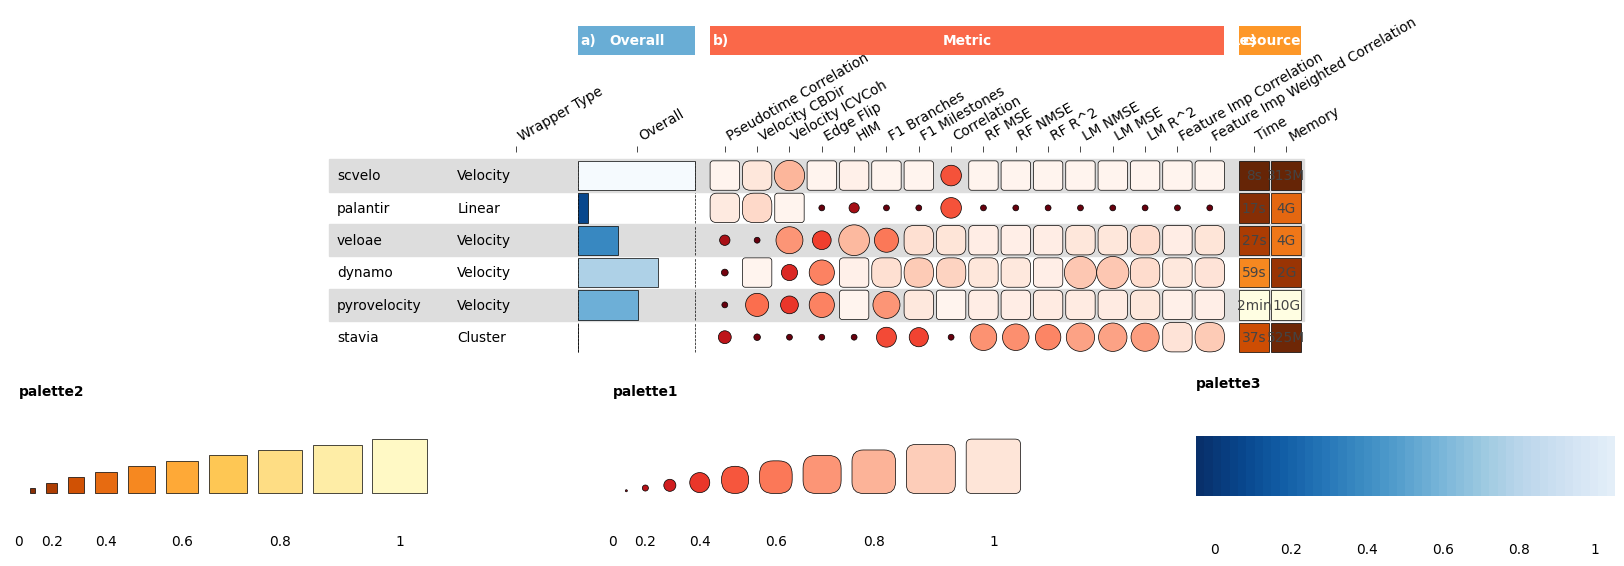

In [42]:
import matplotlib.pyplot as plt
import funkyheatmappy

# plt.figure(figsize=(32, 24))

# 样式参考dynbenchmark: https://funkyheatmap.github.io/funkyheatmap/articles/dynbenchmark.html
column_list = [
    ["id", "group", "name", "geom", "options", "palette"],
    ["id", np.nan, "", "text", {"ha": 0, "width": 4}, np.nan],
    ["type", np.nan, "Wrapper Type", "text", {"ha": 0, "width": 4}, np.nan],
    ["overall", "overall", "Overall", "bar", {"width": 4, "legend": False}, "palette3"],
    # metric group, added by latter 'id2name' dict
    # ["pseudotime_correlation", "group1", "Pseudotime Correlation", "funkyrect", "options", "palette1"],
    # ["velocity_cbdir", "group1", "Velocity CBDir", "funkyrect", "options", "palette1"],
    # ["velocity_icvcoh", "group1", "Velocity ICVCoh", "funkyrect", "options", "palette1"],
    # ["edge_flip", "group1", "Edge Flip", "funkyrect", "options", "palette1"],
    # ["him", "group1", "HIM", "funkyrect", "options", "palette1"],
    # ["isomorphic", "group1", "Isomorphic", "funkyrect", "options", "palette1"],
    # ["F1_branches", "group1", "F1 Branches", "funkyrect", "options", "palette1"],
    # ["F1_milestones", "group1", "F1 Milestones", "funkyrect", "options", "palette1"],
    # ["correlation", "group1", "Correlation", "funkyrect", "options", "palette1"],
    # ["rf_mse", "group1", "RF MSE", "funkyrect", "options", "palette1"],
    # ["rf_nmse", "group1", "RF NMSE", "funkyrect", "options", "palette1"],
    # ["rf_rsq", "group1", "RF R^2", "funkyrect", "options", "palette1"],
    # ["lm_nmse", "group1", "LM NMSE", "funkyrect", "options", "palette1"],
    # ["lm_mse", "group1", "LM MSE", "funkyrect", "options", "palette1"],
    # ["lm_rsq", "group1", "LM R^2", "funkyrect", "options", "palette1"],
    # ["featureimp_cor", "group1", "Feature Imp Correlation", "funkyrect", "options", "palette1"],
    # ["featureimp_wcor", "group1", "Feature Imp Weighted Correlation", "funkyrect", "options", "palette1"],
    # resource group
    ["time", "group2", "Time", "rect", "scaling", "palette2"],
    ["time_text", "group2", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"],  # add time value text
    ["memory", "group2", "Memory", "rect", "scaling", "palette2"],
    ["memory_text", "group2", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"],  # add memory value text

]

id2name = {
    "pseudotime_correlation": "Pseudotime Correlation",
    "velocity_cbdir": "Velocity CBDir",
    "velocity_icvcoh": "Velocity ICVCoh",
    "edge_flip": "Edge Flip",
    "him": "HIM",
    # "isomorphic": "Isomorphic",
    "F1_branches": "F1 Branches",
    "F1_milestones": "F1 Milestones",
    "correlation": "Correlation",
    "rf_mse": "RF MSE",
    "rf_nmse": "RF NMSE",
    "rf_rsq": "RF R^2",
    "lm_nmse": "LM NMSE",
    "lm_mse": "LM MSE",
    "lm_rsq": "LM R^2",
    "featureimp_cor": "Feature Imp Correlation",
    "featureimp_wcor": "Feature Imp Weighted Correlation",
}

metric_column_list = []
for id, name in id2name.items():
    metric_column_list.append([id, "group1", name, "funkyrect", "options", "palette1"])
column_list = column_list[:4] + metric_column_list + column_list[4:]

column_info = pd.DataFrame(column_list[1:], columns=column_list[0])
column_info.index = column_info["id"]

column_groups = pd.DataFrame(
    columns=["Category", "group", "palette"],
    data=[["Overall", "overall", "palette3"],
          ["Metric", "group1", "palette1"],
          ["Resources", "group2", "palette2"]]
)

funkyheatmappy.funky_heatmap(benchmark_df, column_info=column_info, column_groups=column_groups)

plt.savefig("benchmark_heatmap.pdf", dpi=300)
plt.show()